#**Import the Libraries**

In [73]:
!pip install pandas numpy scikit-learn seaborn matplotlib

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [74]:
import numpy as np                          # For numerical operations with arrays
import pandas as pd                         # For data manipulation and DataFrame management
import seaborn as sns                       # For statistical data visualization
import matplotlib.pyplot as plt      

# For creating static, animated, and interactive visualizations
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler  # For scaling features
from sklearn.model_selection import train_test_split, cross_val_score  # For splitting data and cross-validation
from sklearn.linear_model import LogisticRegression  # For logistic regression modeling
from sklearn.metrics import (classification_report,
                             accuracy_score,
                             confusion_matrix,
                             ConfusionMatrixDisplay,
                             roc_curve,
                             auc)  # For evaluating model performance

### Next Steps

1. **Load your data** (using `pandas`).
2. **Exploratory Data Analysis (EDA)**.
3. **Preprocess your data** (handle missing values, encode categorical variables, scale features).
4. **Split your data** into training and testing sets.
5. **Train your model** using a classifier (like `LogisticRegression`).
6. **Evaluate your model** using metrics like accuracy, precision, recall, F1 score, and AUC.
7. **Visualize results** using plots from `seaborn` or `matplotlib`.


In [75]:
import os
import pandas as pd

# See which file is inside the downloaded dataset
print(os.listdir(path))

['healthcare-dataset-stroke-data.csv']


#1. **Loading Data**

In [76]:
df = pd.read_csv(
    os.path.join(path, "healthcare-dataset-stroke-data.csv")
)


#2. **Exploratory Data Analysis (EDA)**
   - **Data Summary**: Get basic statistics of the dataset.
   - **Distribution of Target Variable**: Visualize how many instances belong to each class.
   - **Pairplot**: View relationships between features colored by the outcome.
   - **Correlation Heatmap**: Examine correlations between features to gauge their relationships.
   - **Missing Values**: Check for any missing values.






In [77]:
df.head() # Display the first 5 rows of the dataset

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [78]:
df.tail(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5100,68398,Male,82.0,1,0,Yes,Self-employed,Rural,71.97,28.3,never smoked,0
5101,36901,Female,45.0,0,0,Yes,Private,Urban,97.95,24.5,Unknown,0
5102,45010,Female,57.0,0,0,Yes,Private,Rural,77.93,21.7,never smoked,0
5103,22127,Female,18.0,0,0,No,Private,Urban,82.85,46.9,Unknown,0
5104,14180,Female,13.0,0,0,No,children,Rural,103.08,18.6,Unknown,0
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [79]:
df.describe() # Data Summary

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [80]:
df.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

It seems like you're referring to the data types of your dataset again, specifically emphasizing the integer (`int64`) and float (`float64`) types. In the context of your earlier message, this is how the different types are categorized:

### Data Types:
- **`int64`**: This data type represents 64-bit integers and is used for whole number values without decimals. In your dataset, the columns using this type will store:
  - **Pregnancies**
  - **Glucose**
  - **Blood Pressure**
  - **Skin Thickness**
  - **Insulin**
  - **Age**
  - **Outcome**

- **`float64`**: This data type represents 64-bit floating-point numbers, allowing for decimal values. In your dataset, the columns that use this type are:
  - **BMI**: Body Mass Index
  - **Diabetes Pedigree Function**: A measure based on family history of diabetes.

### Summary:
- **`int64`**: Whole numbers
- **`float64`**: Decimal numbers



In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [82]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [83]:
df.shape

(5110, 12)

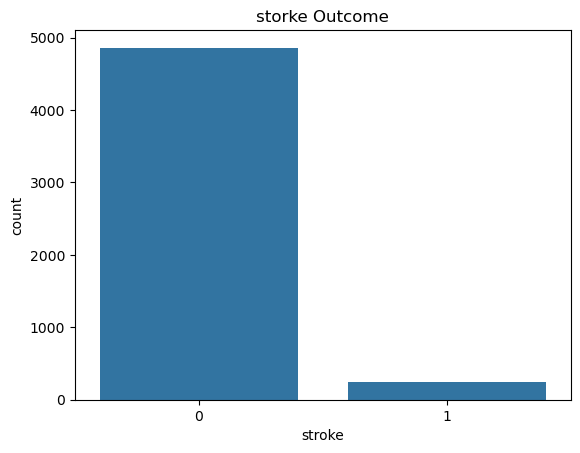

In [84]:
## Visualize the distribution of the target variable
sns.countplot(x='stroke', data=df)
plt.title('storke Outcome')
plt.show()

In [85]:
# Count the occurrences of each outcome
outcome_counts = df['stroke'].value_counts()
total = outcome_counts.sum()
percentages = (outcome_counts / total) * 100  # Calculate percentages

# Combine counts and percentages into a DataFrame
outcome_summary = pd.DataFrame({
    'Counts': outcome_counts,
    'Percentages': percentages
})

print(outcome_summary)

        Counts  Percentages
stroke                     
0         4861    95.127202
1          249     4.872798


In [86]:
# Calculate mean of numerical features grouped by stroke outcome

numeric_features = [
    'age',
    'hypertension',
    'heart_disease',
    'avg_glucose_level',
    'bmi'
]

feature_means = df.groupby('stroke')[numeric_features].mean()

print(feature_means)

              age  hypertension  heart_disease  avg_glucose_level        bmi
stroke                                                                      
0       41.971545      0.088871       0.047110         104.795513  28.823064
1       67.728193      0.265060       0.188755         132.544739  30.471292


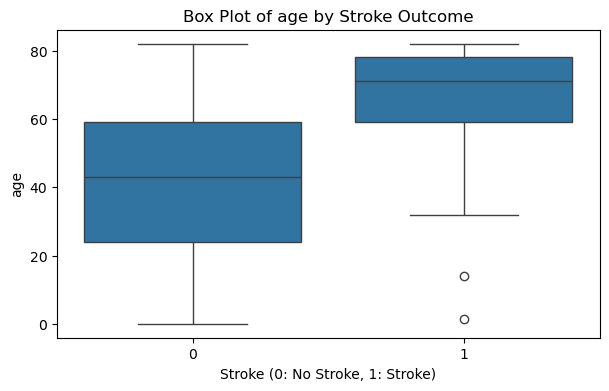

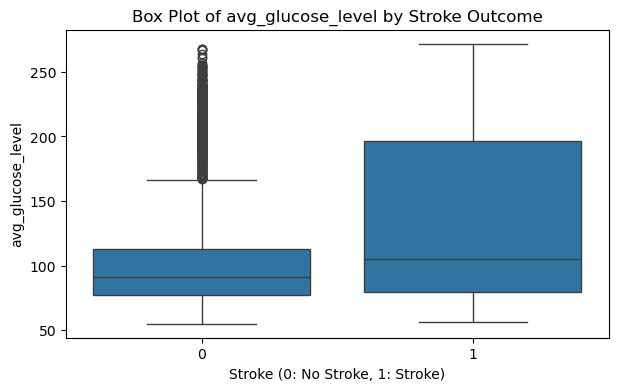

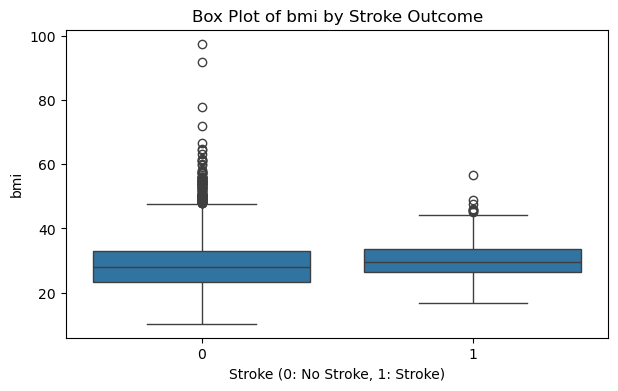

In [87]:
# Create box plots for selected numerical features

features_to_plot = [
    'age',
    'avg_glucose_level',
    'bmi'
]

for feature in features_to_plot:
    plt.figure(figsize=(7, 4))
    
    sns.boxplot(
        x='stroke',
        y=feature,
        data=df
    )
    
    plt.title(f'Box Plot of {feature} by Stroke Outcome')
    plt.xlabel('Stroke (0: No Stroke, 1: Stroke)')
    plt.ylabel(feature)
    
    plt.show()

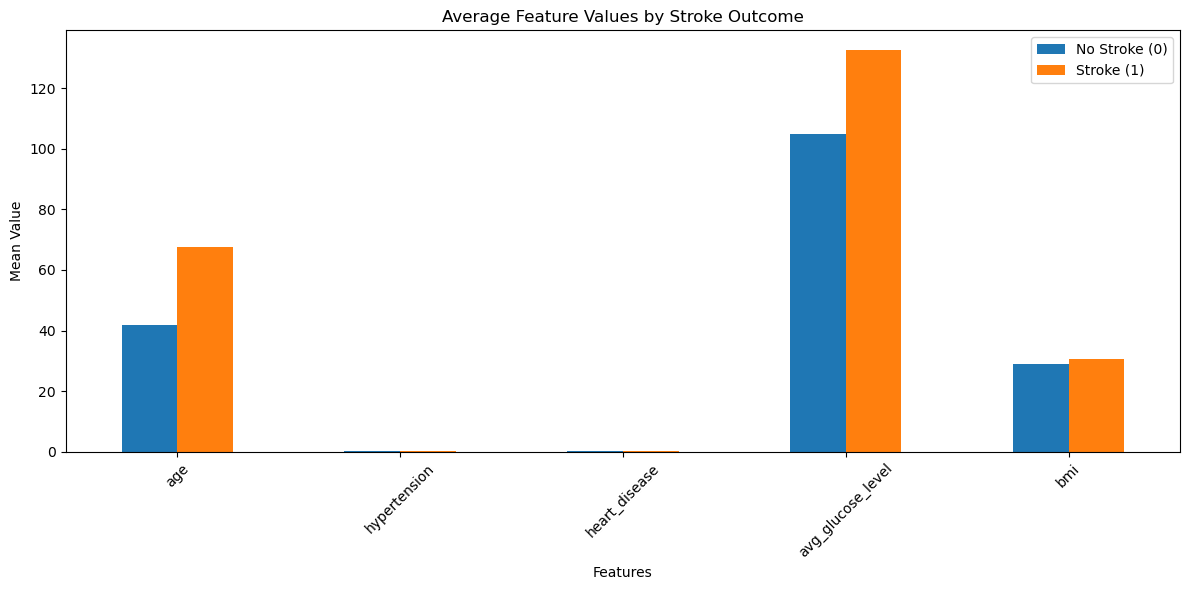

In [88]:
# Bar plot of the average numerical feature values by stroke outcome

feature_means.T.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Average Feature Values by Stroke Outcome')
plt.xlabel('Features')
plt.ylabel('Mean Value')
plt.xticks(rotation=45)
plt.legend(['No Stroke (0)', 'Stroke (1)'])

plt.tight_layout()
plt.show()

#To determine which differences in the features of the Pima Indian Diabetes dataset are statistically significant (with a p-value less than 0.05), we can conduct hypothesis tests for each feature based on `Outcome`. A common approach is to use the independent t-test since this dataset has two groups (Diabetes: 1, No Diabetes: 0).



In [89]:
from scipy import stats

In [90]:
from scipy import stats
import pandas as pd

# Function to perform Welch's t-test
def perform_ttest(feature):
    
    # Split data into two groups based on stroke outcome
    group1 = df[df['stroke'] == 0][feature].dropna()
    group2 = df[df['stroke'] == 1][feature].dropna()

    # Perform Welch's t-test
    t_stat, p_value = stats.ttest_ind(
        group1,
        group2,
        equal_var=False
    )

    return p_value


# Dictionary to hold results
results = {}

# Continuous numerical features in YOUR stroke dataset
features_to_test = [
    'age',
    'avg_glucose_level',
    'bmi'
]


# Perform t-test for each feature
for feature in features_to_test:
    p_value = perform_ttest(feature)
    results[feature] = p_value


# Convert results to DataFrame
results_df = pd.DataFrame.from_dict(
    results,
    orient='index',
    columns=['p-value']
).reset_index()

results_df.rename(
    columns={'index': 'Feature'},
    inplace=True
)

print(results_df)

             Feature       p-value
0                age  2.115685e-95
1  avg_glucose_level  2.401437e-11
2                bmi  3.339710e-04


In [91]:
# Filter significant features
significant_features = results_df[results_df['p-value'] < 0.05]

print("Significant Features (p-value < 0.05):")
print(significant_features)

Significant Features (p-value < 0.05):
             Feature       p-value
0                age  2.115685e-95
1  avg_glucose_level  2.401437e-11
2                bmi  3.339710e-04


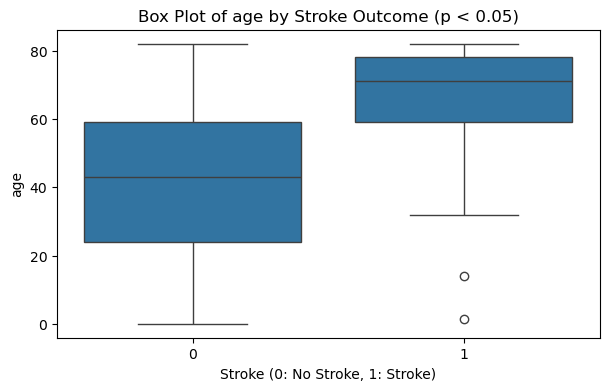

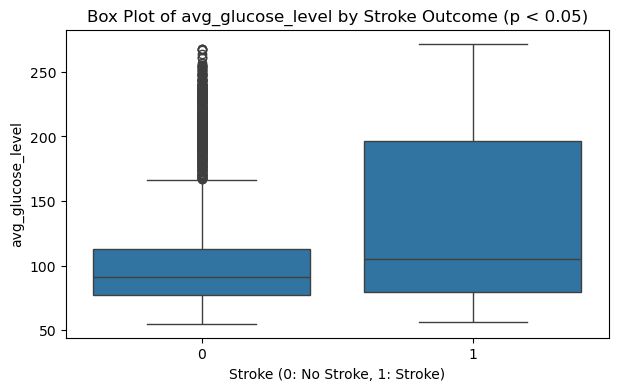

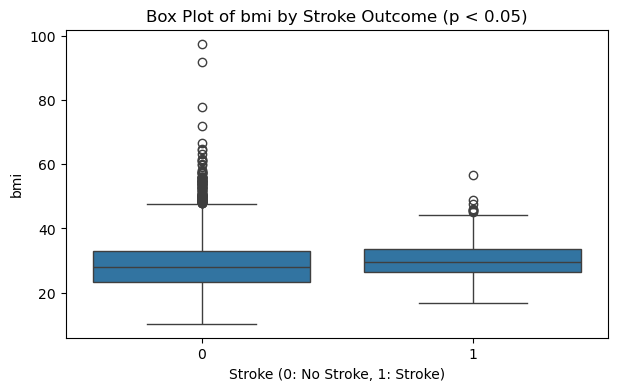

In [92]:
# Visualize significant features

for feature in significant_features['Feature']:
    
    plt.figure(figsize=(7, 4))
    
    sns.boxplot(
        x='stroke',
        y=feature,
        data=df
    )
    
    plt.title(f'Box Plot of {feature} by Stroke Outcome (p < 0.05)')
    plt.xlabel('Stroke (0: No Stroke, 1: Stroke)')
    plt.ylabel(feature)
    
    plt.show()

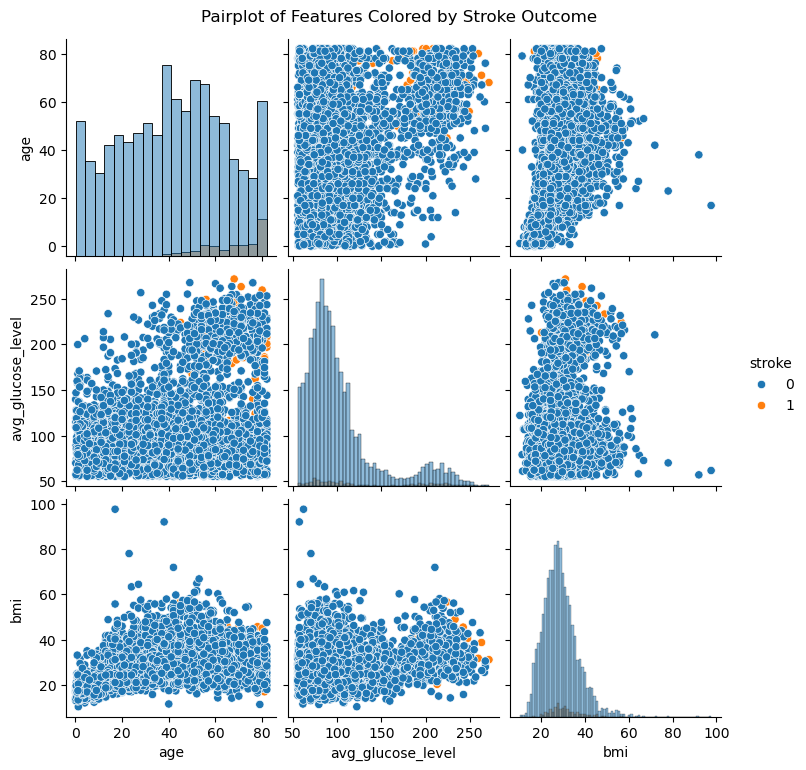

In [93]:
# Pairplot to visualize relationships between continuous features

features_for_pairplot = [
    'age',
    'avg_glucose_level',
    'bmi',
    'stroke'
]

sns.pairplot(
    df[features_for_pairplot].dropna(),
    hue='stroke',
    diag_kind='hist'
)

plt.suptitle(
    'Pairplot of Features Colored by Stroke Outcome',
    y=1.02
)

plt.show()

This is a scatter matrix (pairplot) that analyzes the relationships among several features in a dataset. Here, each row and column represents a feature from the data, and scatter plots between each pair of features are displayed. Additionally, different colored points (typically blue and orange) represent two different categories of outcomes.

This type of analysis aids in gaining a better understanding of the data and the relationships between features, while also identifying key variables for modeling and prediction.


**Distribution of Features:**

On the diagonal of the matrix, the distribution of each feature is shown as a histogram or density curve. These distributions can indicate whether the features are normally distributed or not.

**Relationships Between Features:**

The scatter plots between features reveal potential correlations. For example, if points in a scatter plot tend to align closely along a straight line, it indicates a strong relationship between those two features.

**Difference Between Categories:**

The blue and orange points denote two different outcome categories. If points from the two categories are clearly separated in a scatter plot, this suggests that the feature may be useful for predicting the outcome.

**Key Features:**

By analyzing the scatter plots, one can identify features that may be important for predicting the outcome. For instance, features like "Glucose" and "BMI" may display a stronger correlation with the outcome.

**Outliers:**

The presence of outliers in some plots can influence the analysis and requires further investigation.



#Correlation Check

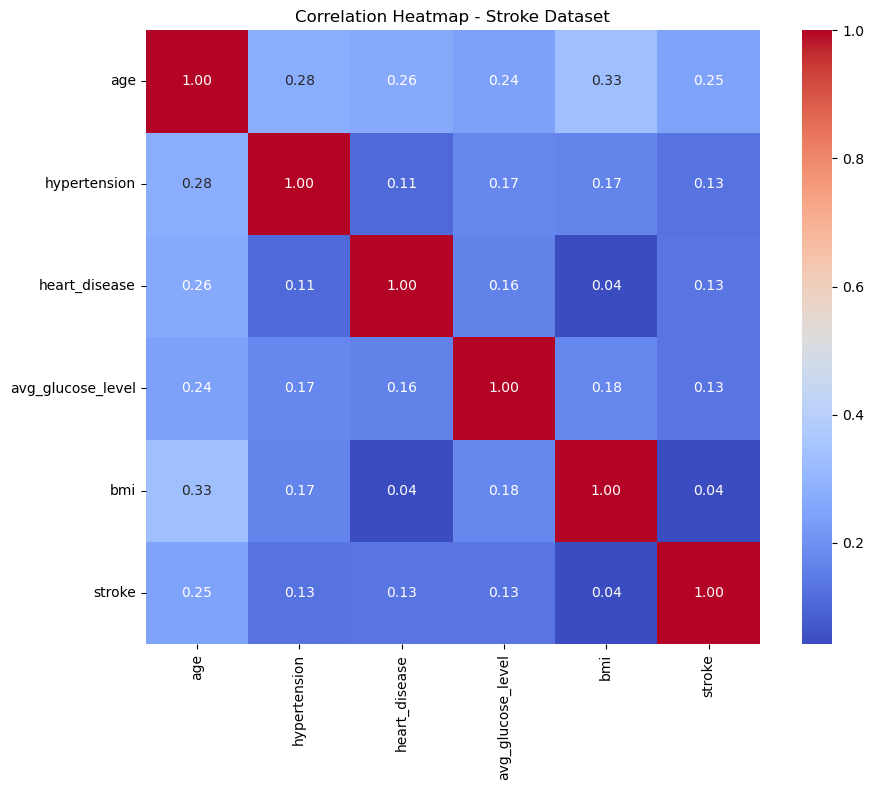

In [94]:
# Correlation heatmap for numerical features

numeric_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['id'])

plt.figure(figsize=(10, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Correlation Heatmap - Stroke Dataset")
plt.tight_layout()
plt.show()

In [95]:
# Calculate correlation only for numerical columns
correlation_matrix = df.select_dtypes(include='number').corr()

# Remove ID because it is only an identifier
correlation_matrix = correlation_matrix.drop(
    index='id',
    columns='id'
)

correlation_matrix

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
age,1.000000,0.276398,0.263796,0.238171,0.333398,0.245257
hypertension,0.276398,1.000000,0.108306,0.174474,0.167811,0.127904
heart_disease,0.263796,0.108306,1.000000,0.161857,0.041357,0.134914
avg_glucose_level,0.238171,0.174474,0.161857,1.000000,0.175502,0.131945
bmi,0.333398,0.167811,0.041357,0.175502,1.000000,0.042374
stroke,0.245257,0.127904,0.134914,0.131945,0.042374,1.000000


In [96]:
# Find very strongly correlated feature pairs
strong_corrs = correlation_matrix[
    (correlation_matrix.abs() > 0.9) &
    (correlation_matrix.abs() < 1.0)
]

strong_corr_pairs = strong_corrs.stack().reset_index()

strong_corr_pairs.columns = [
    'Variable 1',
    'Variable 2',
    'Correlation'
]

print("Strong Correlations (|Correlation| > 0.9):")
print(strong_corr_pairs)

Strong Correlations (|Correlation| > 0.9):
Empty DataFrame
Columns: [Variable 1, Variable 2, Correlation]
Index: []



### Key Points on Correlation

1. **Correlation Coefficient Range**:
   - The correlation coefficient (r) ranges from -1 to 1.
     - **1**: Perfect positive correlation (as one variable increases, the other also increases).
     - **0**: No correlation (no predictable relationship).
     - **-1**: Perfect negative correlation (as one variable increases, the other decreases).

2. **Interpreting Correlation Values**:
   - **0.9 and -0.9**: Indicates a strong positive and negative relationship, respectively.
   - **0.2**: Suggests a weak relationship, meaning changes in one variable do not reliably predict changes in the other.

3. **Examples from Your Data**:
   - **Perfect Correlation**: "Duration" with itself (1.000000) is expected.
   - **Good Correlation**: "Duration" and "Calories" (0.922721) indicates a strong link, supporting the idea that longer workouts burn more calories.
   - **Bad Correlation**: "Duration" and "Maxpulse" (0.009403) shows almost no relationship, suggesting that workout duration does not predict max pulse effectively.

### Additional Considerations

- **Correlation vs. Causation**: Remember that correlation does not imply causation. Just because two variables are correlated does not mean one causes the other.
- **Outliers**: Outliers can significantly affect correlation coefficients, so it’s essential to analyze your data for any extreme values.
- **Data Visualization**: Visualizing data with scatter plots can help illustrate the relationship between variables and make it easier to spot trends or outliers.



#**Checking for miss values**

Checking for missing values using the command `isna()` or `isnull()`




In [97]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

#Miss values in Specific Column

In [98]:
df["bmi"].isnull().sum()

201

In [99]:
# Fill missing BMI values with the median BMI
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# Check again
print(df.isnull().sum())

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


#**Handling miss values**


Handling null (or missing) values is indeed a crucial step in data preparation for machine learning. Missing values can lead to biased models, inaccurate predictions, and other issues if not addressed properly.





In [100]:
print(df.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
5105    False
5106    False
5107    False
5108    False
5109    False
Length: 5110, dtype: bool


In [101]:
df.drop_duplicates(inplace = True)

# Define features and target variable


In [102]:
# Define features and target variable

# X = predictor variables
X = df.drop(columns=['stroke', 'id'])

# y = target variable
y = df['stroke']

In [103]:
y

0       1
1       1
2       1
3       1
4       1
       ..
5105    0
5106    0
5107    0
5108    0
5109    0
Name: stroke, Length: 5110, dtype: int64

#4. **Split your data**

In [104]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (4088, 10)
Testing set: (1022, 10)


In [105]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (4088, 10)
y_train: (4088,)
X_test: (1022, 10)
y_test: (1022,)


In [106]:
X_test

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
3725,Male,63.0,0,0,Yes,Private,Rural,78.23,34.8,never smoked
4481,Female,43.0,0,0,Yes,Private,Urban,86.67,33.3,never smoked
1545,Female,23.0,0,0,No,Private,Urban,126.67,28.7,smokes
1820,Female,21.0,0,0,No,Private,Urban,208.17,24.9,never smoked
1262,Male,67.0,0,0,Yes,Private,Rural,113.34,26.3,formerly smoked
...,...,...,...,...,...,...,...,...,...,...
1042,Female,82.0,0,0,No,Self-employed,Urban,82.21,26.0,never smoked
1171,Female,34.0,0,0,No,Govt_job,Rural,120.06,33.0,never smoked
3199,Female,50.0,0,0,Yes,Govt_job,Urban,92.15,20.8,never smoked
3208,Male,15.0,0,0,No,children,Rural,62.57,32.3,never smoked




#5. **Model Training**



# **Logistic Regression**

In [112]:
# Numerical columns
numeric_features = [
    'age',
    'hypertension',
    'heart_disease',
    'avg_glucose_level',
    'bmi'
]

# Categorical columns
categorical_features = [
    'gender',
    'ever_married',
    'work_type',
    'Residence_type',
    'smoking_status'
]

# Numerical preprocessing
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

###**iterations** refer to the number of times the algorithm updates its parameters to minimize or maximize an objective function, often related to loss or error.





In [140]:
logreg = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

logreg.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'hypertension',
                                                   'heart_disease',
                                                   'avg_glucose_level',
                                                   'bmi']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'Residence_type',
                                                   'smoking_status'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])



   **Model Evaluation**

    - Classification Report: Displays precision, recall, F1-score, and support.
    - Accuracy Score: Shows the overall accuracy of the model.
    - Confusion Matrix: Visualizes true positives, false positives, true negatives, and false negatives.
    - ROC Curve: Plots the true positive rate against the false positive rate and shows the AUC.



Displaying how well the model's predictions (stored in `logreg_pred`) matched the actual test labels (`y_test`).

Accuracy Score: 74.56%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022



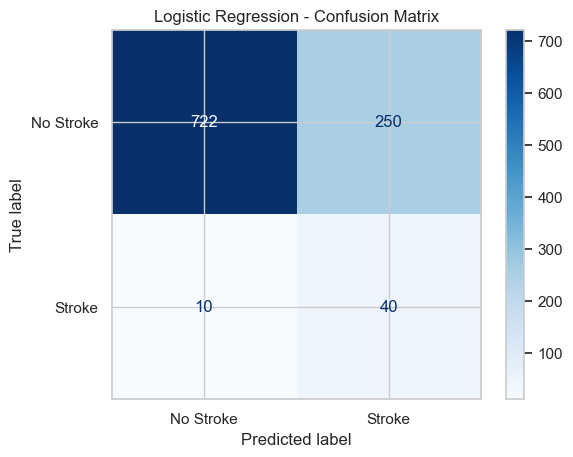

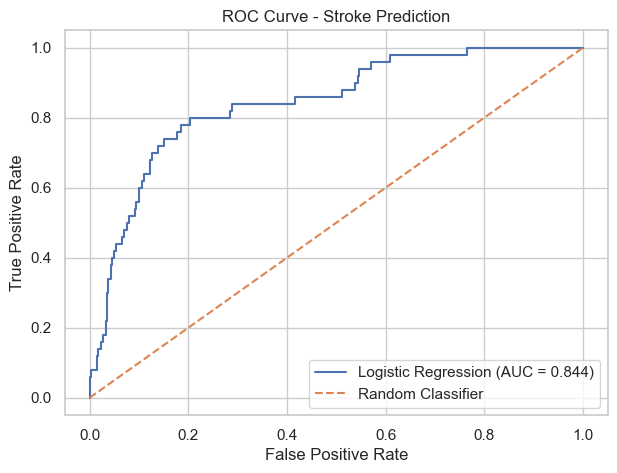

In [142]:
# ==========================================
# Logistic Regression - Model Evaluation
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt


# 1. Make predictions
logreg_pred = logreg.predict(X_test)

# 2. Accuracy
logreg_score = accuracy_score(y_test, logreg_pred) * 100

print(f"Accuracy Score: {logreg_score:.2f}%")

# 3. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, logreg_pred))


# 4. Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    logreg,
    X_test,
    y_test,
    display_labels=["No Stroke", "Stroke"],
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()


# 5. Predicted probabilities for Stroke
y_pred_proba = logreg.predict_proba(X_test)[:, 1]


# 6. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

roc_auc = auc(fpr, tpr)


# 7. Plot ROC Curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Stroke Prediction")
plt.legend()
plt.show()

Text(0.5, 1.0, 'ROC Curve for Diabetes Classification')

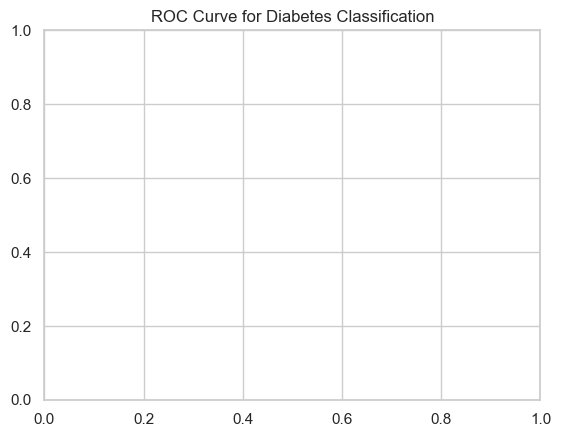


1. **Precision**: This indicates the correctness of the positive predictions.
   - Precision for class 0: 0.81 (81% of instances predicted as class 0 were actually class 0)
   - Precision for class 1: 0.64 (64% of instances predicted as class 1 were actually class 1)

2. **Recall**: This indicates how well the model identifies actual positives.
   - Recall for class 0: 0.79 (79% of actual class 0 instances were correctly identified)
   - Recall for class 1: 0.67 (67% of actual class 1 instances were correctly identified)

3. **F1-Score**: This is the harmonic mean of precision and recall, providing a balance between the two.
   - F1-score for class 0: 0.80
   - F1-score for class 1: 0.65



- **Accuracy**: Overall performance of the model; 0.75 (75% of the predictions were correct).
- **Macro Average**: This calculates the average of the metrics (precision, recall, F1-score) for each class without considering the number of instances in each class. Here it’s:
  - Precision: 0.73
  - Recall: 0.73
  - F1-score: 0.73


### Interpretation:
- Generally, the model performs reasonably well with an overall accuracy of 75%.
  


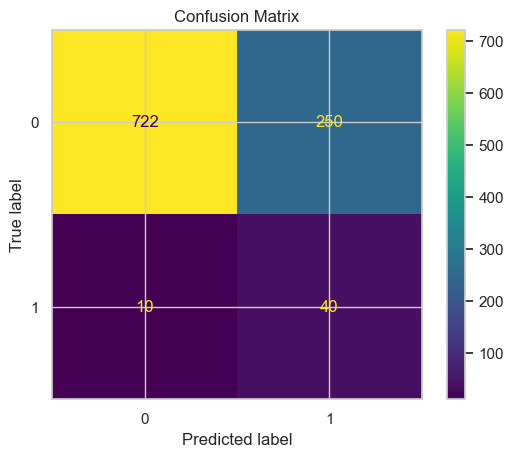

In [144]:
# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(logreg, X_test, y_test)
plt.title('Confusion Matrix')
plt.show()

The code visualizes the confusion matrix for the logistic regression model (`logreg`) using the test dataset (`x_test`, `y_test`).
   - `x_test`: The test dataset features to make predictions.
   - `y_test`: The true labels for the test dataset.



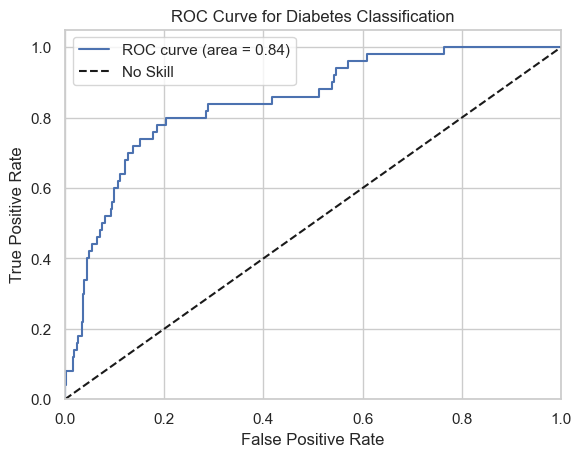

In [145]:
# ROC Curve
y_pred_proba = logreg.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Diabetes Classification')
plt.legend()
plt.show()



 **Cross-Validation**

 Optionally perform cross-validation to assess how well the model generalizes.



In [147]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    logreg,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print("Cross-validation ROC-AUC scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())

Cross-validation ROC-AUC scores: [0.8426749  0.83559671 0.83430041 0.84559671 0.84147493]
Mean ROC-AUC: 0.8399287298592182


In [149]:
lr_model = logreg.named_steps['classifier']

print("Coefficients:")
print(lr_model.coef_)

Coefficients:
[[ 1.8799324   0.17647004  0.05268729  0.1991132   0.05207083 -0.08898948
  -0.2194559  -0.00955581 -0.07929291 -0.23870828 -0.25484213 -0.04370004
  -0.23063459 -0.47131143  0.682487   -0.23434959 -0.08365159 -0.15654362
  -0.00502959 -0.32521014  0.16878216]]


In [150]:

# Get fitted Logistic Regression model
lr_model = logreg.named_steps['classifier']

# Get fitted preprocessor
fitted_preprocessor = logreg.named_steps['preprocessor']

# Get feature names AFTER preprocessing
feature_names = fitted_preprocessor.get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = lr_model.coef_[0]

# Create DataFrame
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Odds Ratio': np.exp(coefficients)
})

# Sort by coefficient
coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

print(coef_df)

                                Feature  Coefficient  Odds Ratio
0                              num__age     1.879932    6.553062
14              cat__work_type_children     0.682487    1.978793
3                num__avg_glucose_level     0.199113    1.220320
1                     num__hypertension     0.176470    1.192999
20           cat__smoking_status_smokes     0.168782    1.183862
2                    num__heart_disease     0.052687    1.054100
4                              num__bmi     0.052071    1.053450
18  cat__smoking_status_formerly smoked    -0.005030    0.994983
7                     cat__gender_Other    -0.009556    0.990490
11          cat__work_type_Never_worked    -0.043700    0.957241
8                  cat__ever_married_No    -0.079293    0.923769
16            cat__Residence_type_Urban    -0.083652    0.919752
5                    cat__gender_Female    -0.088989    0.914855
17          cat__smoking_status_Unknown    -0.156544    0.855094
6                      ca

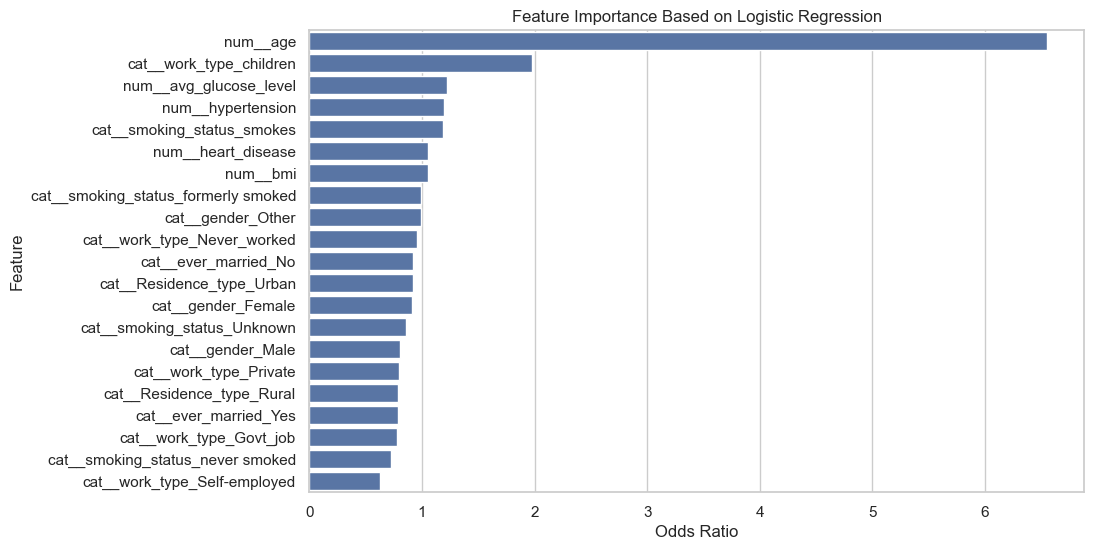

In [151]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Odds Ratio', y='Feature', data=coef_df.sort_values(by='Odds Ratio', ascending=False))
plt.title('Feature Importance Based on Logistic Regression')
plt.xlabel('Odds Ratio')
plt.ylabel('Feature')
plt.show()

#Data Scaling

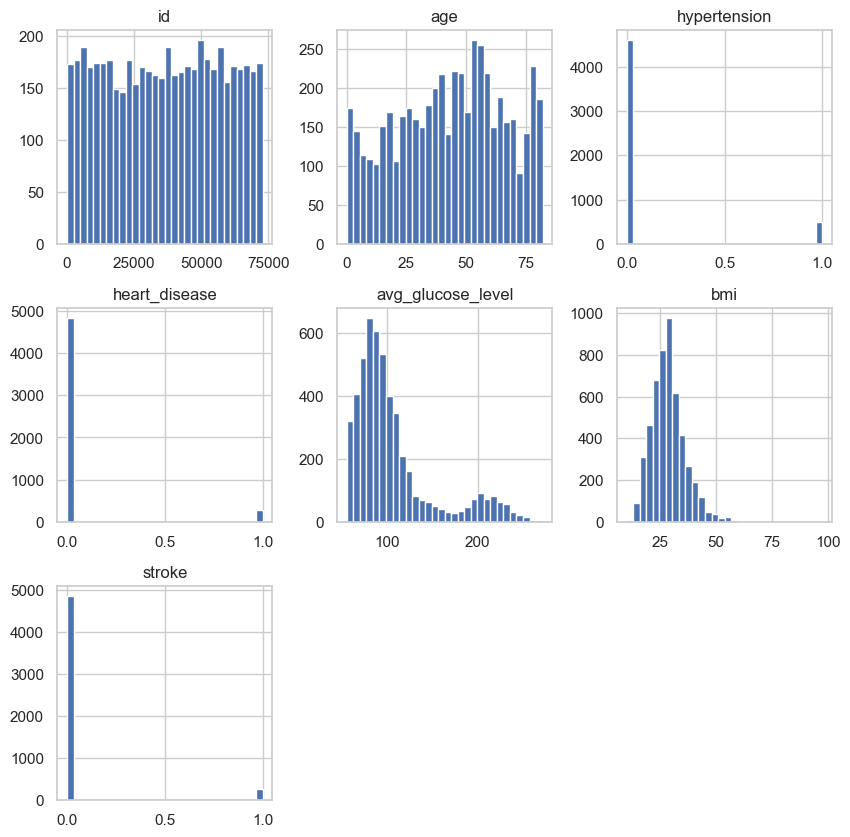

In [152]:
# Check the distribution of features
df.hist(figsize=(10, 10), bins=30)
plt.show()

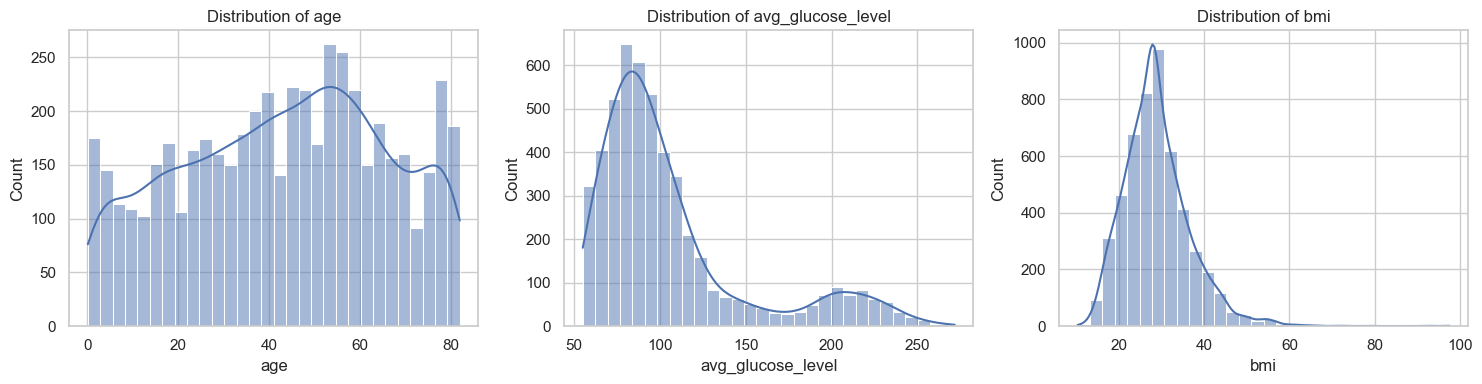

In [154]:
# Distribution of continuous features

continuous_features = [
    'age',
    'avg_glucose_level',
    'bmi'
]

plt.figure(figsize=(15, 4))

for i, column in enumerate(continuous_features):
    
    plt.subplot(1, 3, i + 1)
    
    sns.histplot(
        data=df,
        x=column,
        kde=True,
        bins=30
    )
    
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

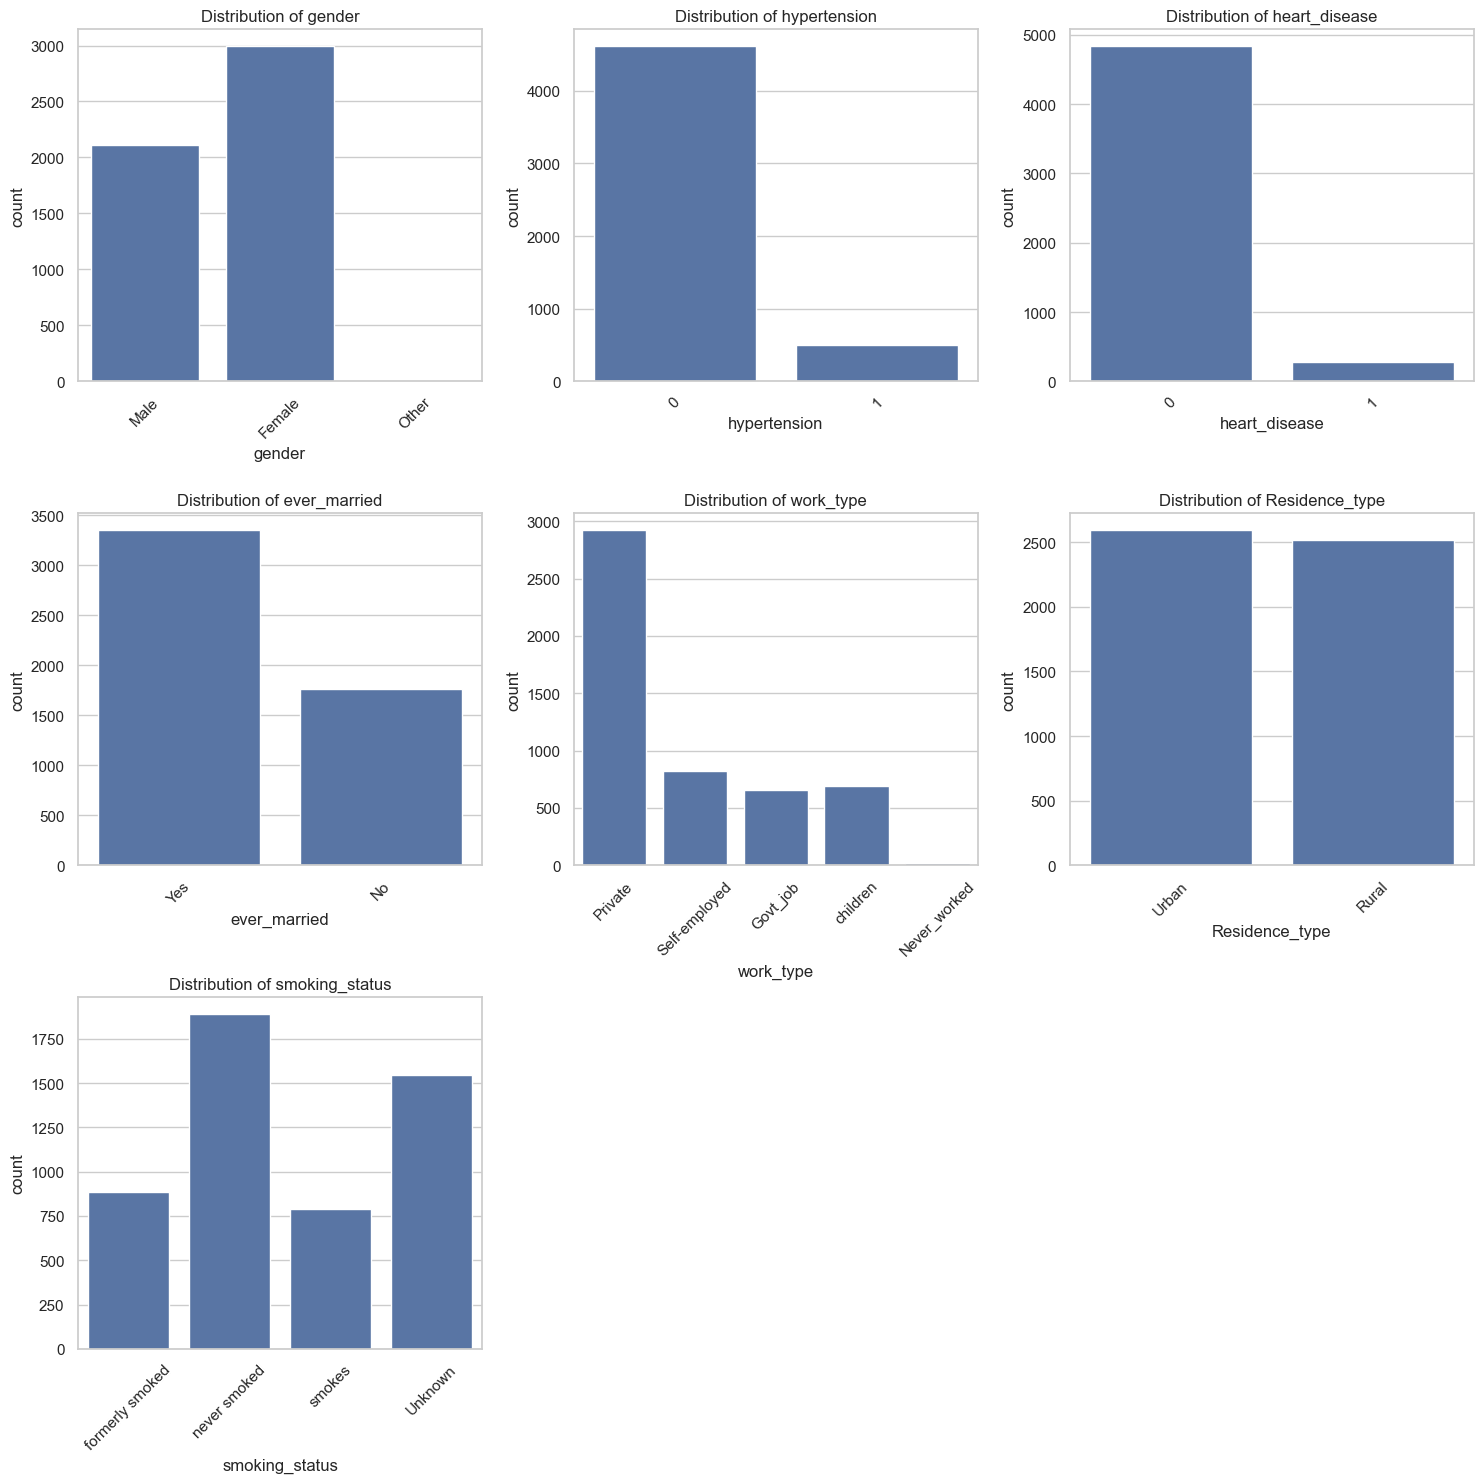

In [155]:
categorical_features = [
    'gender',
    'hypertension',
    'heart_disease',
    'ever_married',
    'work_type',
    'Residence_type',
    'smoking_status'
]

plt.figure(figsize=(15, 15))

for i, column in enumerate(categorical_features):
    
    plt.subplot(3, 3, i + 1)
    
    sns.countplot(
        data=df,
        x=column
    )
    
    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [157]:
# Calculate means and standard deviations for numerical columns only

numeric_df = df.select_dtypes(include='number').drop(columns=['id'])

means = numeric_df.mean()
stds = numeric_df.std()

print("Means:\n", means)
print("\nStandard Deviations:\n", stds)

Means:
 age                   43.226614
hypertension           0.097456
heart_disease          0.054012
avg_glucose_level    106.147677
bmi                   28.862035
stroke                 0.048728
dtype: float64

Standard Deviations:
 age                  22.612647
hypertension          0.296607
heart_disease         0.226063
avg_glucose_level    45.283560
bmi                   7.699562
stroke                0.215320
dtype: float64


# **Logistic Regression with Standard Scaler**

Standard Scaler helps to get standardized distribution, with a zero mean and standard deviation of one (unit variance). It standardizes features by subtracting the mean value from the feature and then dividing the result by feature standard deviation. The standard scaling is calculated as: z = (x - u) / s.

Accuracy: 0.7455968688845401

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022



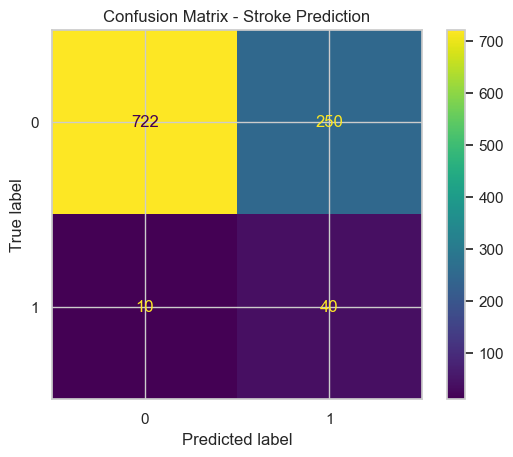

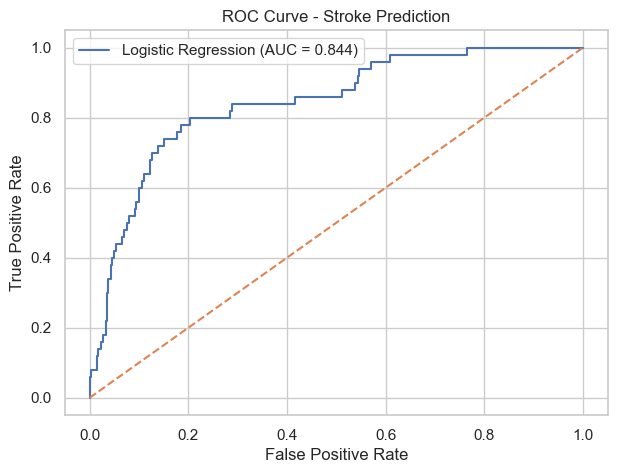

5-Fold ROC-AUC scores: [0.8426749  0.83559671 0.83430041 0.84559671 0.84147493]
Mean ROC-AUC: 0.8399287298592182
Standard deviation: 0.0043012210008663955


In [158]:
# Logistic Regression with preprocessing for Stroke Dataset

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
import matplotlib.pyplot as plt
import numpy as np


# ---------------------------------------------------
# 1. Define features and target
# ---------------------------------------------------

X = df.drop(columns=['stroke', 'id'])
y = df['stroke']


# ---------------------------------------------------
# 2. Define numerical and categorical features
# ---------------------------------------------------

numeric_features = [
    'age',
    'hypertension',
    'heart_disease',
    'avg_glucose_level',
    'bmi'
]

categorical_features = [
    'gender',
    'ever_married',
    'work_type',
    'Residence_type',
    'smoking_status'
]


# ---------------------------------------------------
# 3. Numerical preprocessing
# ---------------------------------------------------

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


# ---------------------------------------------------
# 4. Categorical preprocessing
# ---------------------------------------------------

categorical_transformer = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


# ---------------------------------------------------
# 5. Combine preprocessing
# ---------------------------------------------------

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


# ---------------------------------------------------
# 6. Train-test split
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ---------------------------------------------------
# 7. Logistic Regression pipeline
# ---------------------------------------------------

logreg = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])


# ---------------------------------------------------
# 8. Train model
# ---------------------------------------------------

logreg.fit(X_train, y_train)


# ---------------------------------------------------
# 9. Predictions
# ---------------------------------------------------

logreg_pred = logreg.predict(X_test)
logreg_proba = logreg.predict_proba(X_test)[:, 1]


# ---------------------------------------------------
# 10. Evaluation
# ---------------------------------------------------

print("Accuracy:", accuracy_score(y_test, logreg_pred))

print("\nClassification Report:")
print(classification_report(y_test, logreg_pred))


# ---------------------------------------------------
# 11. Confusion Matrix
# ---------------------------------------------------

ConfusionMatrixDisplay.from_estimator(
    logreg,
    X_test,
    y_test
)

plt.title("Confusion Matrix - Stroke Prediction")
plt.show()


# ---------------------------------------------------
# 12. ROC Curve
# ---------------------------------------------------

fpr, tpr, thresholds = roc_curve(y_test, logreg_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {roc_auc:.3f})'
)

plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Stroke Prediction")
plt.legend()

plt.show()


# ---------------------------------------------------
# 13. 5-Fold Cross-Validation
# ---------------------------------------------------

cv_scores = cross_val_score(
    logreg,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print("5-Fold ROC-AUC scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())


1. **Creates a StandardScaler instance**: `scaler = StandardScaler()`
2. **Fits and transforms the training data**: `x_train_scaled = scaler.fit_transform(x_train)` - This step calculates the mean and standard deviation from `x_train`, then scales the training data accordingly.
3. **Transforms the test data**: `x_test_scaled = scaler.transform(x_test)` - This step scales the test data using the mean and standard deviation calculated from the training data, ensuring that the test data is transformed in the same way as the training data.



# **Decision Tree Classifier**

In [162]:
from sklearn.tree import DecisionTreeClassifier

Accuracy: 0.8278

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.83      0.90       972
           1       0.18      0.70      0.28        50

    accuracy                           0.83      1022
   macro avg       0.58      0.77      0.59      1022
weighted avg       0.94      0.83      0.87      1022

ROC-AUC: 0.8192


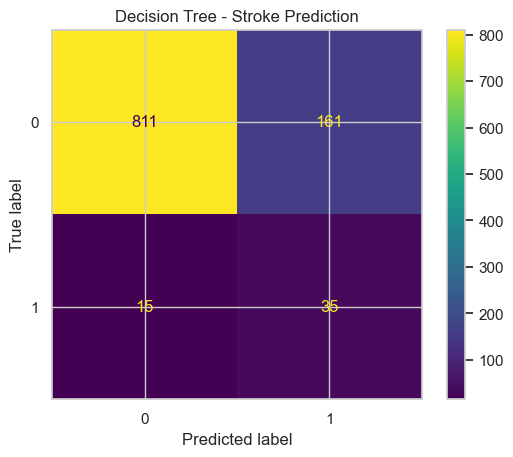

5-Fold ROC-AUC scores: [0.77966049 0.73436214 0.77340535 0.7842284  0.79636932]
Mean ROC-AUC: 0.7736051394280322
Standard deviation: 0.021013241797664426


In [164]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score
)
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt


# ---------------------------------------------------
# 1. Create Decision Tree Pipeline
# ---------------------------------------------------

dt = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=5,
        class_weight='balanced',
        random_state=42
    ))
])


# ---------------------------------------------------
# 2. Train the model
# ---------------------------------------------------

dt.fit(X_train, y_train)


# ---------------------------------------------------
# 3. Make predictions
# ---------------------------------------------------

dt_pred = dt.predict(X_test)

# Probability of stroke (class 1)
dt_proba = dt.predict_proba(X_test)[:, 1]


# ---------------------------------------------------
# 4. Accuracy
# ---------------------------------------------------

dt_accuracy = accuracy_score(y_test, dt_pred)

print(f"Accuracy: {dt_accuracy:.4f}")


# ---------------------------------------------------
# 5. Classification Report
# ---------------------------------------------------

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))


# ---------------------------------------------------
# 6. ROC-AUC
# ---------------------------------------------------

dt_auc = roc_auc_score(y_test, dt_proba)

print(f"ROC-AUC: {dt_auc:.4f}")


# ---------------------------------------------------
# 7. Confusion Matrix
# ---------------------------------------------------

ConfusionMatrixDisplay.from_estimator(
    dt,
    X_test,
    y_test
)

plt.title("Decision Tree - Stroke Prediction")
plt.show()


# ---------------------------------------------------
# 8. 5-Fold Cross Validation
# ---------------------------------------------------

dt_cv = cross_val_score(
    dt,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print("5-Fold ROC-AUC scores:", dt_cv)
print("Mean ROC-AUC:", dt_cv.mean())
print("Standard deviation:", dt_cv.std())

#Hyperparameter Tuning

In [166]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline


# ---------------------------------------------------
# Decision Tree Pipeline
# ---------------------------------------------------

dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ))
])


# ---------------------------------------------------
# Hyperparameter Grid
# ---------------------------------------------------

param_grid = {
    'classifier__max_depth': [2, 3, 4, 5, 6, 7, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}


# ---------------------------------------------------
# Grid Search
# ---------------------------------------------------

grid_search = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)


# ---------------------------------------------------
# Train
# ---------------------------------------------------

grid_search.fit(X_train, y_train)


# ---------------------------------------------------
# Results
# ---------------------------------------------------

print("Best Hyperparameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(grid_search.best_score_)

Best Hyperparameters:
{'classifier__max_depth': 2, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}

Best Cross-Validation ROC-AUC:
0.821338114541842


Test Accuracy: 0.5851272015655578

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.57      0.72       972
           1       0.09      0.84      0.17        50

    accuracy                           0.59      1022
   macro avg       0.54      0.71      0.44      1022
weighted avg       0.94      0.59      0.70      1022

Test ROC-AUC: 0.8145267489711934


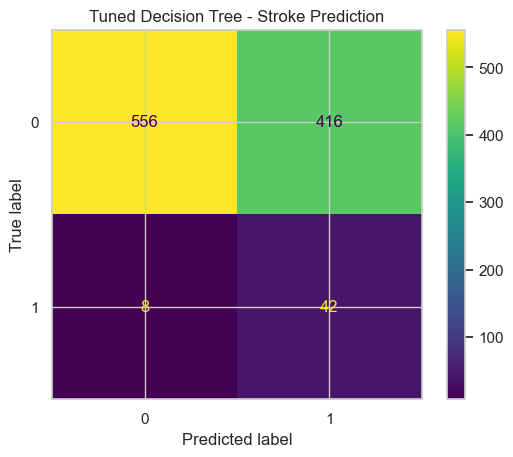

In [167]:
# Best Decision Tree found by GridSearchCV
best_dt = grid_search.best_estimator_

# Predictions
best_dt_pred = best_dt.predict(X_test)
best_dt_proba = best_dt.predict_proba(X_test)[:, 1]

# Evaluation
print("Test Accuracy:",
      accuracy_score(y_test, best_dt_pred))

print("\nClassification Report:")
print(classification_report(y_test, best_dt_pred))

print("Test ROC-AUC:",
      roc_auc_score(y_test, best_dt_proba))


# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    best_dt,
    X_test,
    y_test
)

plt.title("Tuned Decision Tree - Stroke Prediction")
plt.show()

# **Random Forest Classifier**

#Feature Importance with Random Forest




Random Forest Accuracy: 0.9501

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

ROC-AUC: 0.7641


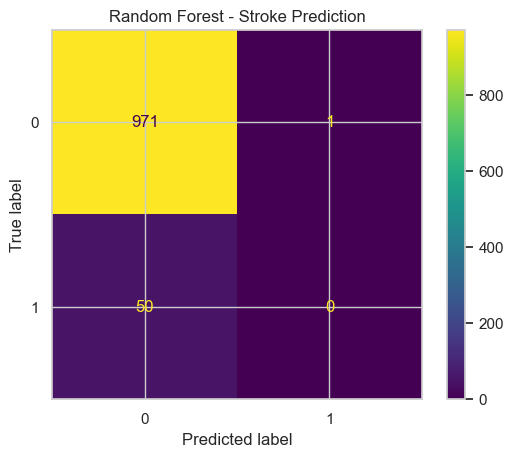

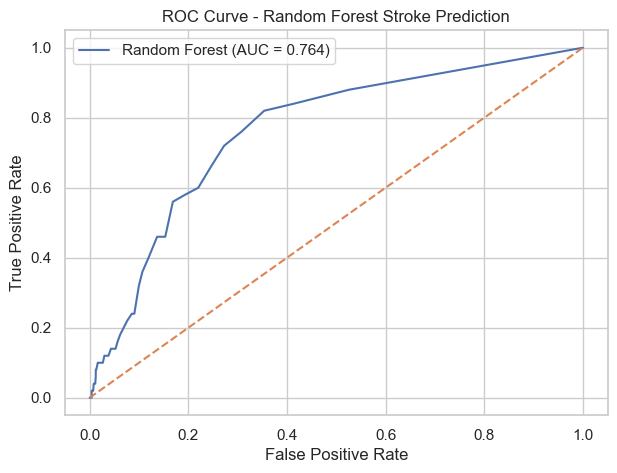

5-Fold ROC-AUC scores: [0.80471193 0.78705761 0.78371399 0.79306584 0.75358139]
Mean ROC-AUC: 0.7844261548325318
Standard deviation: 0.01699993083916062


In [168]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt


# ---------------------------------------------------
# 1. Create Random Forest Pipeline
# ---------------------------------------------------

rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    ))
])


# ---------------------------------------------------
# 2. Train Random Forest
# ---------------------------------------------------

rf.fit(X_train, y_train)


# ---------------------------------------------------
# 3. Make predictions
# ---------------------------------------------------

rf_pred = rf.predict(X_test)

# Probability of stroke
rf_proba = rf.predict_proba(X_test)[:, 1]


# ---------------------------------------------------
# 4. Accuracy
# ---------------------------------------------------

rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")


# ---------------------------------------------------
# 5. Classification Report
# ---------------------------------------------------

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))


# ---------------------------------------------------
# 6. ROC-AUC
# ---------------------------------------------------

rf_auc = roc_auc_score(y_test, rf_proba)

print(f"ROC-AUC: {rf_auc:.4f}")


# ---------------------------------------------------
# 7. Confusion Matrix
# ---------------------------------------------------

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title("Random Forest - Stroke Prediction")
plt.show()


# ---------------------------------------------------
# 8. ROC Curve
# ---------------------------------------------------

fpr, tpr, thresholds = roc_curve(y_test, rf_proba)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f'Random Forest (AUC = {rf_auc:.3f})'
)

plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest Stroke Prediction")
plt.legend()

plt.show()


# ---------------------------------------------------
# 9. 5-Fold Cross Validation
# ---------------------------------------------------

rf_cv = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print("5-Fold ROC-AUC scores:", rf_cv)
print("Mean ROC-AUC:", rf_cv.mean())
print("Standard deviation:", rf_cv.std())

                                Feature  Importance
0                              num__age    0.369478
3                num__avg_glucose_level    0.184505
4                              num__bmi    0.170877
1                     num__hypertension    0.032127
8                  cat__ever_married_No    0.021809
2                    num__heart_disease    0.021109
9                 cat__ever_married_Yes    0.020146
19     cat__smoking_status_never smoked    0.019169
13         cat__work_type_Self-employed    0.017562
18  cat__smoking_status_formerly smoked    0.017030
12               cat__work_type_Private    0.016856
16            cat__Residence_type_Urban    0.016083
6                      cat__gender_Male    0.014973
20           cat__smoking_status_smokes    0.014386
5                    cat__gender_Female    0.014137
17          cat__smoking_status_Unknown    0.014020
15            cat__Residence_type_Rural    0.013849
10              cat__work_type_Govt_job    0.011812
14          

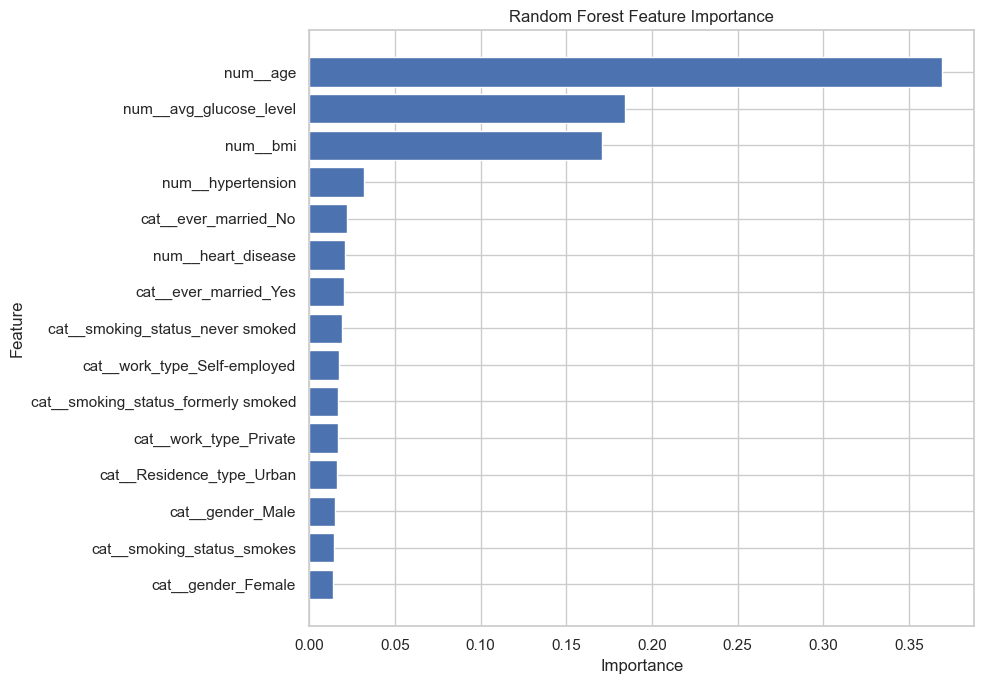

In [169]:
# Get trained Random Forest from pipeline
rf_model = rf.named_steps['classifier']

# Get transformed feature names
feature_names = rf.named_steps['preprocessor'].get_feature_names_out()

# Get feature importances
importances = rf_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort from most important to least important
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_df)

# Plot
plt.figure(figsize=(10, 7))

top_features = feature_importance_df.head(15)

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# **Compare results**

In [170]:
print("Random Forest Results")
print("---------------------")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"ROC-AUC: {rf_auc:.4f}")
print(f"CV ROC-AUC: {rf_cv.mean():.4f}")

Random Forest Results
---------------------
Accuracy: 0.9501
ROC-AUC: 0.7641
CV ROC-AUC: 0.7844
